# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gulgumusdere/flyrank-internship-ml/blob/main/work/notebooks/w04_signal_audit.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [9]:
import duckdb
from google.colab import userdata

con = duckdb.connect()
con.sql("INSTALL httpfs; LOAD httpfs;")

hf_token = userdata.get('HF_TOKEN')
con.sql(f"""
CREATE OR REPLACE SECRET hf_token (
    TYPE HUGGINGFACE,
    TOKEN '{hf_token}'
)
""")

feature_df = con.sql("""
WITH base AS (
    SELECT
        client_hash_id,
        content_hash_id,
        report_date,
        gsc_impressions,
        gsc_clicks,
        gsc_sum_position,
        gsc_clicks * 1.0 / NULLIF(gsc_impressions, 0) AS ctr,
        gsc_sum_position * 1.0 / NULLIF(gsc_impressions, 0) AS avg_position
    FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
    WHERE gsc_data_available IS TRUE
      AND gsc_impressions >= 50
),
tiered AS (
    SELECT *,
        CASE
            WHEN avg_position <= 3 THEN 'top_3'
            WHEN avg_position <= 10 THEN 'page_1'
            WHEN avg_position <= 20 THEN 'page_2'
            WHEN avg_position <= 50 THEN 'page_3_5'
            ELSE 'deep'
        END AS position_tier
    FROM base
),
tier_medians AS (
    SELECT position_tier, MEDIAN(ctr) AS expected_ctr
    FROM tiered
    GROUP BY position_tier
)
SELECT
    t.*,
    m.expected_ctr,
    m.expected_ctr - t.ctr AS ctr_gap
FROM tiered t
JOIN tier_medians m USING (position_tier)
""").df()

print(feature_df.shape)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(1037442, 11)


## 1. Distributions

**Distributions**

All three key fields are heavily right-skewed:
- gsc_impressions: median 128, mean 240, max 40,084 — a small number of high-traffic pages
  pull the mean well above the median.
- ctr: median 0.0, 75th percentile still near 0.004 — most rows get zero or near-zero clicks;
  the distribution is dominated by a long tail of high-CTR outliers (max 0.21).
- avg_position: median ~6 (page_1 range), but a long tail extends to 210 (deep tier).

Takeaway: means are misleading for all three fields here. Medians and tier-based groupings
(as used in ctr_gap) are more appropriate than raw averages given these tails.

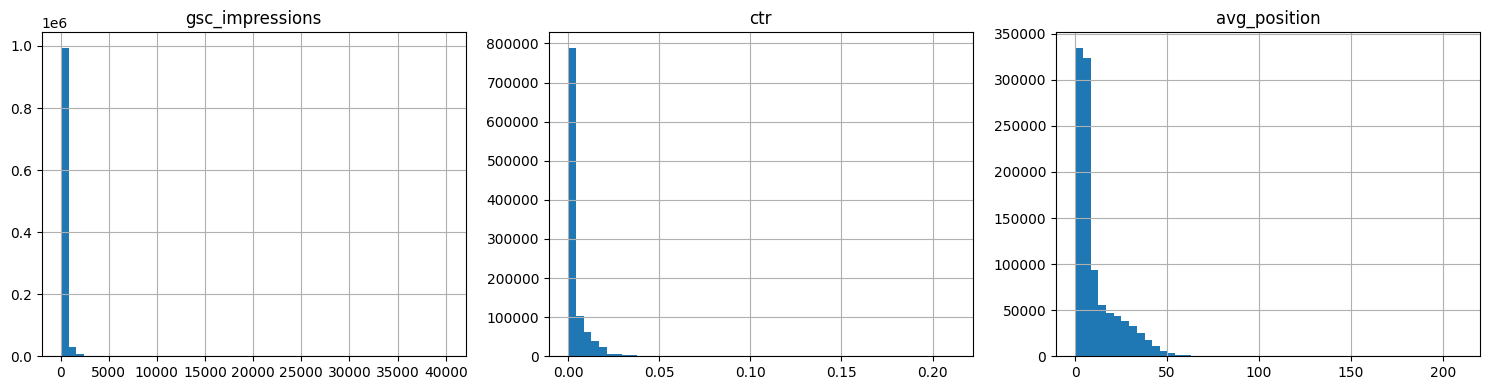

       gsc_impressions           ctr  avg_position
count     1.037442e+06  1.037442e+06  1.037442e+06
mean      2.397757e+02  3.060148e-03  1.099344e+01
std       4.243687e+02  6.274622e-03  1.157224e+01
min       5.000000e+01  0.000000e+00  0.000000e+00
25%       7.700000e+01  0.000000e+00  3.540984e+00
50%       1.280000e+02  0.000000e+00  6.025000e+00
75%       2.500000e+02  3.875969e-03  1.439719e+01
max       4.008400e+04  2.115385e-01  2.098061e+02


In [10]:
# Look at distributions of key fields, note heavy tails
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
feature_df['gsc_impressions'].hist(bins=50, ax=axes[0])
axes[0].set_title('gsc_impressions')
feature_df['ctr'].hist(bins=50, ax=axes[1])
axes[1].set_title('ctr')
feature_df['avg_position'].hist(bins=50, ax=axes[2])
axes[2].set_title('avg_position')
plt.tight_layout()
plt.show()

print(feature_df[['gsc_impressions','ctr','avg_position']].describe())

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

Signal test #1 — Position vs CTR: Correlation is negative as expected (-0.128), confirming the
direction of the relationship. However, the magnitude is weak — raw linear correlation doesn't
capture the tiered/non-linear nature of the position-CTR relationship well. Verdict: MIXED
(direction confirmed, but weak as a standalone linear signal — tier-based grouping likely tells
a clearer story, tested in Signal test #3).

In [11]:
# Signal test 1: Does better position (lower avg_position) correlate with higher CTR?
corr1 = feature_df[['avg_position','ctr']].corr().iloc[0,1]
print("Correlation avg_position vs ctr:", corr1)


Correlation avg_position vs ctr: -0.127582685048838


Signal test #2 — Impressions vs CTR: Mean CTR is nearly flat across impression quintiles
(0.0029–0.0032), with only a slight dip at the highest-impression bucket. There is no
meaningful relationship between how many impressions a page gets and its click-through rate.
Verdict: FALSE (impression volume does not systematically predict CTR).

In [12]:
# Signal test 2: Do higher-impression pages have systematically different CTR?
import pandas as pd
by_impr = feature_df.groupby(pd.qcut(feature_df['gsc_impressions'], 5))['ctr'].mean()
print(by_impr)

gsc_impressions
(49.999, 70.0]      0.003052
(70.0, 103.0]       0.003095
(103.0, 161.0]      0.003207
(161.0, 302.0]      0.003026
(302.0, 40084.0]    0.002922
Name: ctr, dtype: float64


/tmp/ipykernel_4095/2950425200.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_impr = feature_df.groupby(pd.qcut(feature_df['gsc_impressions'], 5))['ctr'].mean()


Signal test #3 — Position tier monotonicity: CTR decreases monotonically and substantially
across tiers — top_3 (0.0038) > page_1 (0.0033) > page_2 (0.0031) > page_3_5 (0.0016) >
deep (0.0004), a ~9x drop from top to bottom. Verdict: CONFIRMED (the tiered relationship
is much clearer than the raw linear correlation in test #1 — position_tier is a well-behaved
signal for grouping/baseline purposes).

In [13]:
tier_order = feature_df.groupby('position_tier', observed=True)['ctr'].mean().sort_values(ascending=False)
print(tier_order)

position_tier
top_3       0.003785
page_1      0.003347
page_2      0.003142
page_3_5    0.001566
deep        0.000408
Name: ctr, dtype: float64


## 3. The flag-linked test

The flag-linked test — needs_engagement_fix assumption: FlyRank's flag assumes a large ctr_gap
(actual CTR far below position-tier peers) signals an engagement problem worth fixing — implying
these two should move together (high ctr_gap → low engagement_rate).

Tested on 18,798 rows with both GSC and GA4 data: correlation between ctr_gap and engagement_rate
is -0.137 — weak, and in the OPPOSITE direction of what the flag's logic assumes. Pages with a
large CTR gap are not showing systematically lower engagement; if anything, the relationship
points slightly the other way.

Verdict: FALSE. The needs_engagement_fix flag's core assumption is not supported by this month's
data — a CTR gap does not reliably predict an engagement problem.

In [14]:
# Check what columns exist in the warehouse beyond what we've pulled
con.sql("""
SELECT *
FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
LIMIT 1
""").df().columns.tolist()


['report_date',
 'client_hash_id',
 'content_hash_id',
 'client_has_gsc',
 'client_has_ga4',
 'gsc_data_available',
 'ga4_data_available',
 'gsc_impressions',
 'gsc_clicks',
 'gsc_sum_position',
 'gsc_avg_position',
 'ga4_pageviews',
 'ga4_sessions',
 'ga4_users',
 'ga4_engaged_sessions',
 'ga4_total_engagement_sec',
 'sessions_organic',
 'sessions_direct',
 'sessions_referral',
 'sessions_social',
 'sessions_paid',
 'sessions_ai',
 'ai_chatgpt',
 'ai_perplexity',
 'ai_gemini',
 'ai_copilot',
 'ai_claude',
 'ai_meta',
 'ai_other',
 'scroll_events',
 'month']

In [15]:
# Pull engagement fields to test the needs_engagement_fix assumption
engagement_df = con.sql("""
SELECT
    client_hash_id,
    content_hash_id,
    gsc_impressions,
    gsc_clicks,
    gsc_sum_position,
    ga4_sessions,
    ga4_engaged_sessions,
    gsc_clicks * 1.0 / NULLIF(gsc_impressions, 0) AS ctr,
    gsc_sum_position * 1.0 / NULLIF(gsc_impressions, 0) AS avg_position,
    ga4_engaged_sessions * 1.0 / NULLIF(ga4_sessions, 0) AS engagement_rate
FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
WHERE gsc_data_available IS TRUE
  AND gsc_impressions >= 50
  AND ga4_data_available IS TRUE
  AND ga4_sessions >= 10
""").df()

# Attach position_tier and ctr_gap the same way as before
engagement_df['position_tier'] = pd.cut(
    engagement_df['avg_position'],
    bins=[-1, 3, 10, 20, 50, 1000],
    labels=['top_3','page_1','page_2','page_3_5','deep']
)
tier_medians = engagement_df.groupby('position_tier', observed=True)['ctr'].median()
engagement_df['expected_ctr'] = engagement_df['position_tier'].map(tier_medians)
engagement_df['ctr_gap'] = engagement_df['expected_ctr'] - engagement_df['ctr']

print(engagement_df.shape)
print(engagement_df[['ctr_gap','engagement_rate']].corr())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(18798, 13)
                  ctr_gap  engagement_rate
ctr_gap          1.000000        -0.137157
engagement_rate -0.137157         1.000000


## 4. What this means in practice
A content team should not treat needs_engagement_fix as evidence of an engagement issue on its
own — the underlying signal doesn't hold up. CTR gap and engagement rate appear to move somewhat
independently, so a page flagged for "engagement fix" may already have healthy engagement, or a
page with real engagement problems may not get flagged at all. The flag should be treated as a
loose triage hint at best, not a diagnosis — teams should check actual engagement metrics before
prioritizing a rewrite based on this flag alone.

In [16]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.